# Test: PDF Loader for Research Papers (PyMuPDF4LLM)

**Why PyMuPDF4LLM (not UnstructuredPDFLoader):**
- Unstructured often fails to detect **tables** and **figures** in dense academic PDFs (e.g. Faster R-CNN).
- **PyMuPDF4LLM** converts pages to **Markdown** with proper reading order, detects **tables**, and records **images/graphics** per page.
- Each page is returned with **metadata**: `source`, `page_number`, `page_count`, `toc_items`, `tables`, `images`, `graphics`.

**Set `PDF_PATH` below** to your research paper PDF (or use the default).

In [21]:
!pip install -q pymupdf4llm pymupdf beautifulsoup4

In [24]:
import os
from pathlib import Path

# --- Set your PDF path here ---
# Example: Cursor workspace copy, or local path
PDF_PATH = os.environ.get("RESEARCH_PDF_PATH", "./input_docs/FasterR_CNN.pdf")

# Cursor workspace path (uncomment and use if your PDF is there):
# PDF_PATH = "/Users/satta/Library/Application Support/Cursor/User/workspaceStorage/fd59e65741a6580b6e550236e2e9f443/pdfs/a5c7b203-34ac-4c56-afbf-271e03daa457/FasterR_CNN.pdf"

if not os.path.isfile(PDF_PATH):
    # Fallback: first PDF in input_docs or ResearchPapers
    for d in ("./input_docs", "./ResearchPapers"):
        if os.path.isdir(d):
            pdfs = sorted(Path(d).glob("*.pdf"))
            if pdfs:
                PDF_PATH = str(pdfs[0])
                break
if not os.path.isfile(PDF_PATH):
    raise FileNotFoundError(f"PDF not found: {PDF_PATH}. Set PDF_PATH or add a PDF to ./input_docs or ./ResearchPapers.")

# List all PDFs for loading second paper (for comparison)
all_pdfs = []
for d in ("./input_docs", "./ResearchPapers"):
    if os.path.isdir(d):
        all_pdfs = sorted(Path(d).glob("*.pdf"))
        if all_pdfs:
            break
PDF_PATH_2 = str(all_pdfs[1]) if len(all_pdfs) > 1 else None

print(f"Using PDF 1: {PDF_PATH}")
print(f"File size: {os.path.getsize(PDF_PATH) / 1024:.1f} KB")
if PDF_PATH_2:
    print(f"Second PDF (for comparison): {PDF_PATH_2}")

Using PDF: ./input_docs/FasterR_CNN.pdf
File size: 2435.8 KB


In [25]:
import pymupdf4llm

# Extract all pages with full metadata (page_chunks=True)
# table_strategy: "lines_strict" (default) or "lines" if tables are not detected
page_chunks = pymupdf4llm.to_markdown(
    PDF_PATH,
    page_chunks=True,
    table_strategy="lines",  # use "lines" for papers where tables have no visible borders
    show_progress=True,
)

print(f"Loaded {len(page_chunks)} pages.")

Processing ./input_docs/FasterR_CNN.pdf...


100%|██████████| 17/17 [00:10<00:00,  1.69it/s]

Loaded 17 pages.


In [26]:
# Build documents with relevant metadata (LangChain-style for downstream use)
from langchain_core.documents import Document

documents_with_metadata = []
for i, chunk in enumerate(page_chunks):
    meta = dict(chunk.get("metadata", {}))
    # Normalize: page_number (1-based); use index+1 if not in metadata
    page_num = meta.get("page_number") or meta.get("page") or (i + 1)
    if isinstance(page_num, int) and "page_number" not in meta:
        meta["page_number"] = page_num
    meta["source"] = meta.get("file_path") or PDF_PATH
    meta["page"] = page_num
    
    text = (chunk.get("text") or "").strip()
    tables = chunk.get("tables") or []
    images = chunk.get("images") or []
    graphics = chunk.get("graphics") or []
    toc = chunk.get("toc_items") or []
    
    # Store structured info in metadata for retrieval
    meta["total_pages"] = len(page_chunks)
    meta["tables_on_page"] = len(tables)
    meta["images_on_page"] = len(images)
    meta["graphics_on_page"] = len(graphics)
    meta["toc_items"] = toc
    
    doc = Document(page_content=text, metadata=meta)
    documents_with_metadata.append(doc)

print(f"Built {len(documents_with_metadata)} documents with metadata.")

Built 17 documents with metadata.


In [27]:
# Show metadata summary for first 3 pages
print("Metadata (first 3 pages):")
print("=" * 60)
for i, doc in enumerate(documents_with_metadata[:3]):
    m = doc.metadata
    print(f"Page {m.get('page_number', m.get('page'))}:")
    print(f"  source: {m.get('source', '')}")
    print(f"  total_pages: {m.get('total_pages')}")
    print(f"  tables_on_page: {m.get('tables_on_page')}")
    print(f"  images_on_page: {m.get('images_on_page')}")
    print(f"  graphics_on_page: {m.get('graphics_on_page')}")
    if m.get("toc_items"):
        print(f"  toc_items: {m['toc_items']}")
    print()

Metadata (first 3 pages):
Page 1:
  source: ./input_docs/FasterR_CNN.pdf
  total_pages: 17
  tables_on_page: 0
  images_on_page: 0
  graphics_on_page: 0
  toc_items: [[1, 'SSD: Single Shot MultiBox Detector', 1]]

Page 2:
  source: ./input_docs/FasterR_CNN.pdf
  total_pages: 17
  tables_on_page: 0
  images_on_page: 0
  graphics_on_page: 0

Page 3:
  source: ./input_docs/FasterR_CNN.pdf
  total_pages: 17
  tables_on_page: 1
  images_on_page: 1
  graphics_on_page: 0



In [28]:
# Show retrieved text for first 2 pages (with metadata header)
MAX_TEXT = 5000
print("Retrieved text (first 2 pages):")
print("=" * 60)
for doc in documents_with_metadata[:2]:
    p = doc.metadata.get("page_number") or doc.metadata.get("page")
    print(f"\n--- Page {p} (source: {doc.metadata.get('source', '')}) ---\n")
    text = doc.page_content or ""
    print(text[:MAX_TEXT] + ("..." if len(text) > MAX_TEXT else ""))
    print()

Retrieved text (first 2 pages):

--- Page 1 (source: ./input_docs/FasterR_CNN.pdf) ---

## **SSD: Single Shot MultiBox Detector**

Wei Liu [1], Dragomir Anguelov [2], Dumitru Erhan [3], Christian Szegedy [3],
Scott Reed [4], Cheng-Yang Fu [1], Alexander C. Berg [1]


1UNC Chapel Hill 2Zoox Inc. 3Google Inc. 4University of Michigan, Ann-Arbor
1wliu@cs.unc.edu, 2drago@zoox.com, 3 _{_ dumitru,szegedy _}_ @google.com,
4reedscot@umich.edu, 1 _{_ cyfu,aberg _}_ @cs.unc.edu


**Abstract.** We present a method for detecting objects in images using a single
deep neural network. Our approach, named SSD, discretizes the output space of
bounding boxes into a set of default boxes over different aspect ratios and scales
per feature map location. At prediction time, the network generates scores for the
presence of each object category in each default box and produces adjustments to
the box to better match the object shape. Additionally, the network combines predictions from multiple feature maps with

In [29]:
# Tables: show all tables found (from page_chunks raw data)
total_tables = 0
for i, chunk in enumerate(page_chunks):
    tables = chunk.get("tables") or []
    page_num = (chunk.get("metadata") or {}).get("page_number") or (i + 1)
    for j, tbl in enumerate(tables):
        total_tables += 1
        print(f"\n--- Table on page {page_num}, table #{j+1} ---")
        print(f"  bbox: {tbl.get('bbox')}")
        print(f"  rows: {tbl.get('row_count')}, cols: {tbl.get('col_count')}")
        # If table has content (e.g. from layout), show it
        if "content" in tbl or "text" in tbl:
            print(tbl.get("content", tbl.get("text", ""))[:1500])
if total_tables == 0:
    print("No table structures detected. Text in tables is still in the page Markdown above.")
else:
    print(f"\nTotal tables detected: {total_tables}")


--- Table on page 3, table #1 ---
  bbox: (262.5588073730469, 36.18207550048828, 357.99603271484375, 132.4996795654297)
  rows: None, cols: None

--- Table on page 4, table #1 ---
  bbox: (69.00210571289062, 33.465091705322266, 349.854736328125, 188.77609252929688)
  rows: None, cols: None

--- Table on page 4, table #2 ---
  bbox: (123.92935180664062, 46.96526336669922, 309.67864990234375, 114.609619140625)
  rows: None, cols: None

--- Table on page 9, table #1 ---
  bbox: (14.084395408630371, 380.2779541015625, 397.03271484375, 501.7847900390625)
  rows: None, cols: None

--- Table on page 9, table #2 ---
  bbox: (41.916744232177734, 44.04350280761719, 151.0019989013672, 257.3477478027344)
  rows: None, cols: None

--- Table on page 9, table #3 ---
  bbox: (61.42959976196289, 52.39619445800781, 138.4861297607422, 137.67266845703125)
  rows: None, cols: None

--- Table on page 9, table #4 ---
  bbox: (155.76678466796875, 44.04350280761719, 267.01409912109375, 257.3477478027344)
  ro

In [30]:
# Images and graphics: list per page
print("Images and graphics (first 5 pages):")
print("=" * 60)
for i, chunk in enumerate(page_chunks[:5]):
    meta = chunk.get("metadata") or {}
    page_num = meta.get("page_number") or (i + 1)
    images = chunk.get("images") or []
    graphics = chunk.get("graphics") or []
    if images or graphics:
        print(f"\nPage {page_num}: {len(images)} image(s), {len(graphics)} graphic(s)")
        for img in images[:3]:
            print(f"  Image: {img}")
        for g in graphics[:3]:
            print(f"  Graphic: {g}")
print("\n(Image/graphic content is referenced in the page Markdown text above.)")

Images and graphics (first 5 pages):

Page 3: 1 image(s), 0 graphic(s)
  Image: {'number': 1, 'bbox': Rect(59.90754699707031, 36.5518798828125, 155.91134643554688, 132.55567932128906), 'transform': (96.00379943847656, 0.0, -0.0, 96.00379943847656, 59.90754699707031, 36.5518798828125), 'width': 479, 'height': 479, 'colorspace': 3, 'cs-name': 'DeviceRGB', 'xres': 96, 'yres': 96, 'bpc': 8, 'size': 119409, 'has-mask': False}

(Image/graphic content is referenced in the page Markdown text above.)


## Display tables and images as they are

- **Tables:** Markdown tables in the page text are parsed and rendered as HTML using **BeautifulSoup** (to build a proper `<table>`) and **IPython.display.HTML** so they look like real tables.
- **Images:** Extracted from the PDF with **PyMuPDF** and shown with **IPython.display.Image** so they appear as in the document.

In [32]:
# Display Markdown tables as HTML (BeautifulSoup + IPython.display)
import re
from bs4 import BeautifulSoup
from IPython.display import display, HTML

def _set_cell_content(tag, cell_text):
    """Set cell content; render <br> as HTML line breaks (so they display as-is)."""
    if not cell_text:
        return
    if "<br" in cell_text.lower():
        # Parse so <br> renders as real line breaks in the table cell
        inner = BeautifulSoup(cell_text.replace("<br>", "<br/>").replace("<br />", "<br/>"), "html.parser")
        for child in list(inner.children):
            tag.append(child)
    else:
        tag.string = cell_text

def markdown_table_to_html(md_text):
    """Parse Markdown table lines (with |) and return an HTML table string."""
    lines = [l.strip() for l in md_text.splitlines() if "|" in l and l.strip()]
    if not lines:
        return None
    # Skip separator line (e.g. |---|---|)
    rows = []
    for line in lines:
        if re.match(r"^\|?[\s\-:]+\|", line):
            continue
        cells = [c.strip() for c in line.split("|") if c.strip() or line.startswith("|")]
        if cells:
            rows.append(cells)
    if not rows:
        return None
    soup = BeautifulSoup("", "html.parser")
    table = soup.new_tag("table", style="border-collapse: collapse; border: 1px solid #ccc; margin: 10px 0;")
    for i, row in enumerate(rows):
        tr = soup.new_tag("tr")
        tag_name = "th" if i == 0 else "td"
        for cell in row:
            td = soup.new_tag(tag_name, style="border: 1px solid #ccc; padding: 6px 10px; text-align: left;")
            _set_cell_content(td, cell)
            tr.append(td)
        table.append(tr)
    return str(table)

# Find and display first few Markdown tables from all pages
table_count = 0
for i, chunk in enumerate(page_chunks):
    text = (chunk.get("text") or "")
    html_table = markdown_table_to_html(text)
    if html_table:
        table_count += 1
        display(HTML(f"<p><b>Page {i+1} – Table {table_count}</b></p>"))
        display(HTML(html_table))
    if table_count >= 5:
        break
if table_count == 0:
    print("No Markdown tables found in page text. Tables may be in plain text form.")

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10,
,,,,,,,,,,,
,,,,,,,,,,,
,,,,,,,,,,,
,,,,,,,,,,,
,,,,,,,,,,,
,,,,,,,,,,,
,loc <br>conf,": ∆(_cx_<br>: (_c_1_, c_",": ∆(_cx_<br>: (_c_1_, c_",": ∆(_cx_<br>: (_c_1_, c_",": ∆(_cx_<br>: (_c_1_, c_","_, cy,_<br> 2_, · · ·_","_ w, h_<br>_, cp_","_ w, h_<br>_, cp_",)<br>),)<br>),


,Cor<br>Loc<br>Sim<br>Oth<br>BG,Col2,Col3,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,Cor<br>Loc<br>Sim<br>Oth<br>BG,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,Col2,Col3,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,Cor<br>Loc<br>Sim<br>Oth<br>BG,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,
,Cor<br>Loc<br>Sim<br>Oth<br>BG,,,


,Prediction source layers from:<br>conv4 3 conv7 conv8 2 conv9 2 conv10 2 conv11 2,mAP<br>use boundary boxes?<br>Yes No,# Boxes,
,<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>,74.3<br>63.4<br>**74.6**<br>63.1<br>73.8<br>68.4<br>70.7<br>69.2<br>64.2<br>64.4<br>62.4<br>64.0,8732<br>8764<br>8942<br>9864<br>9025<br>8664,


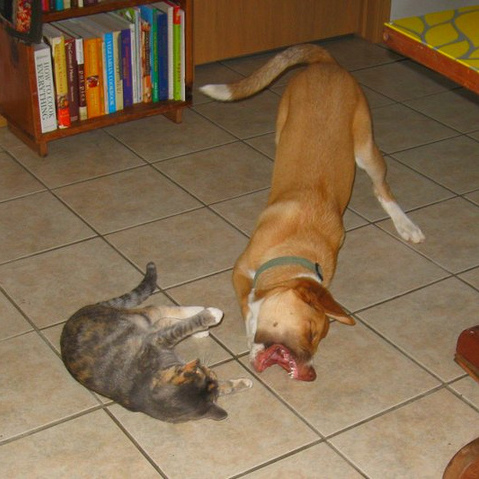

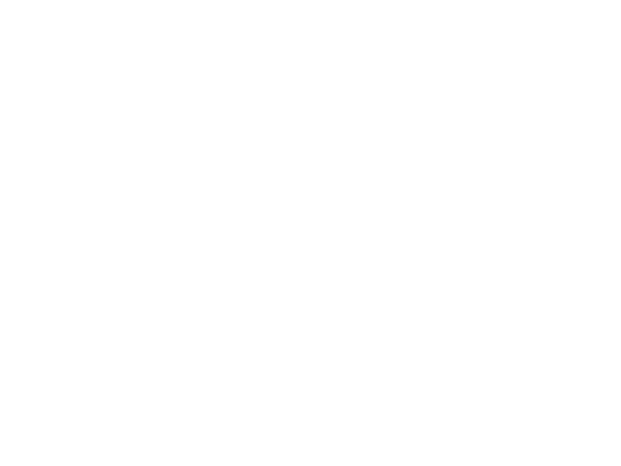

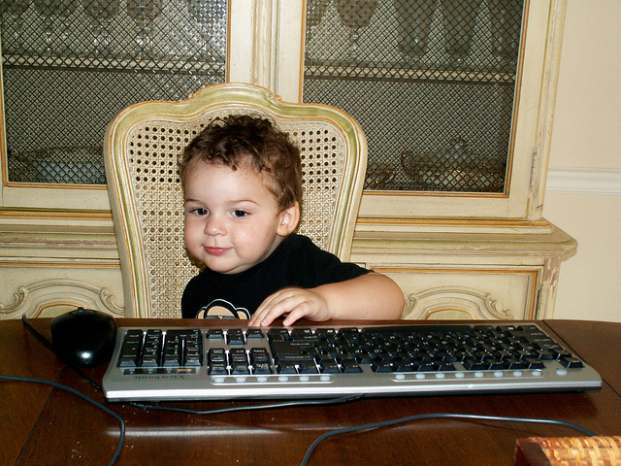

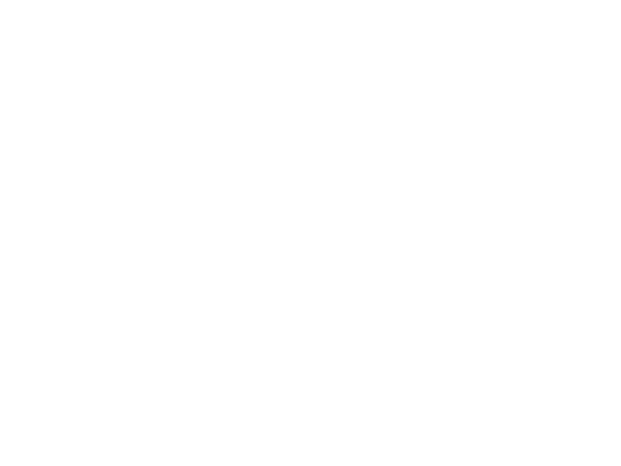

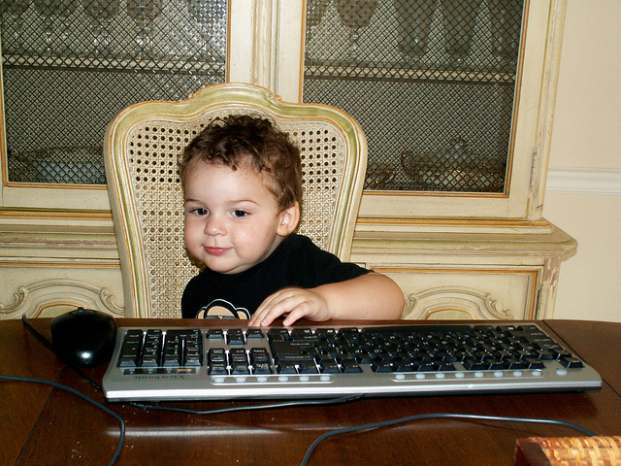

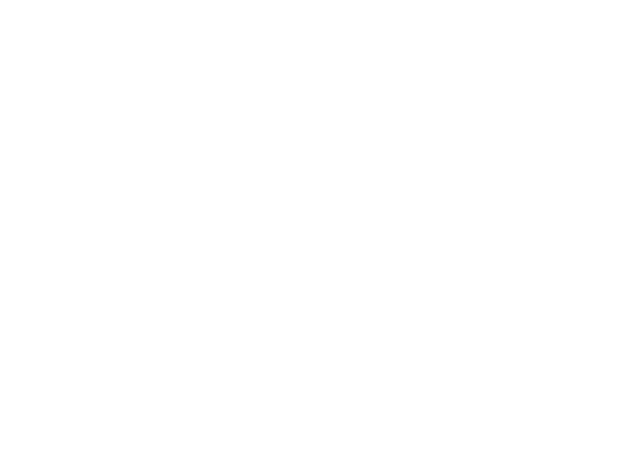

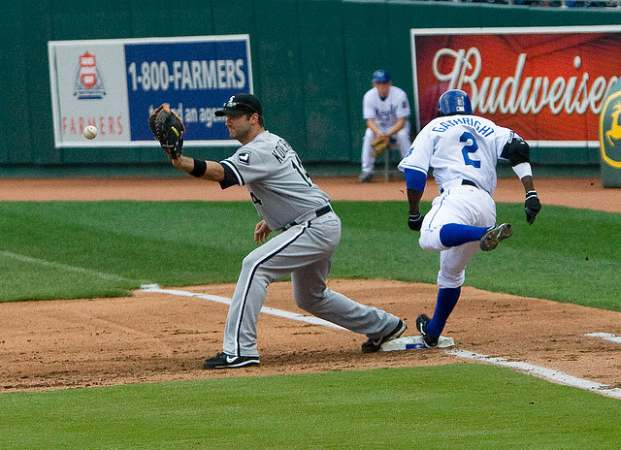

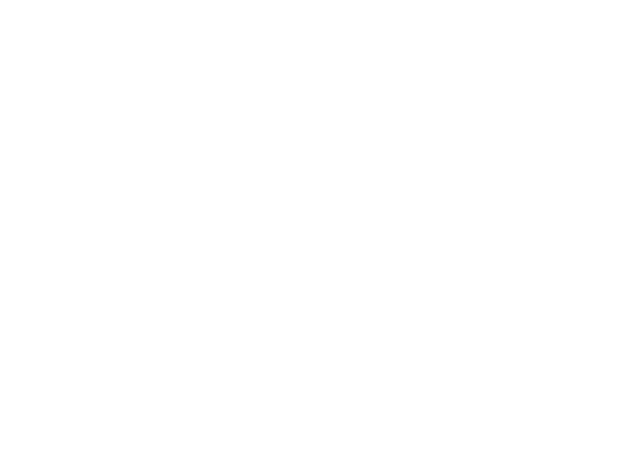

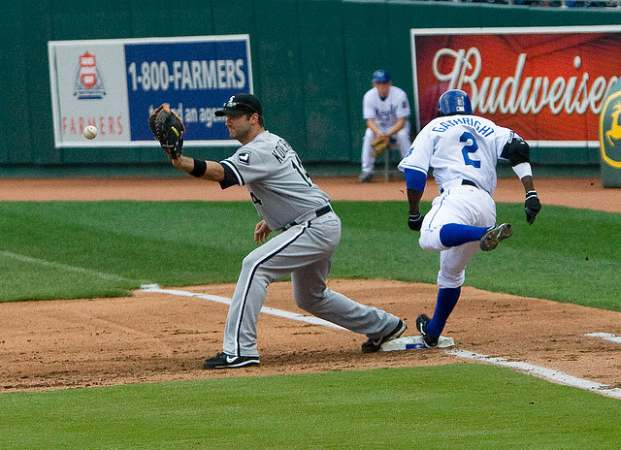

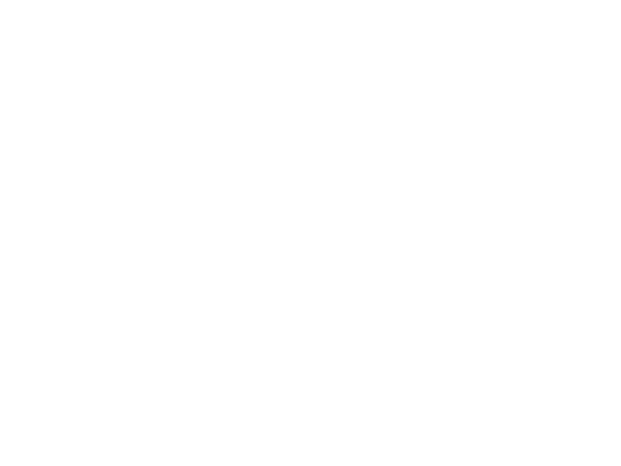

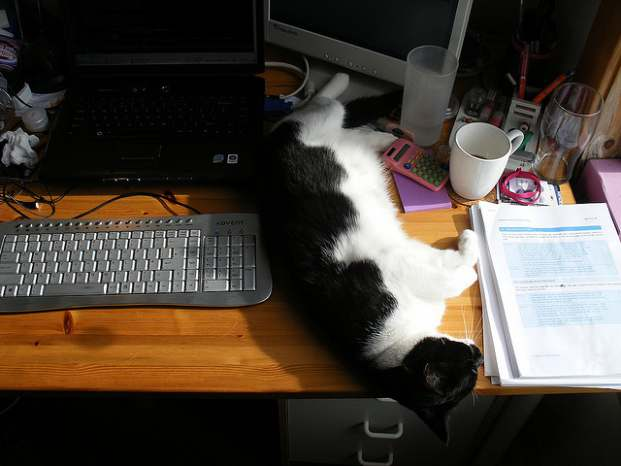

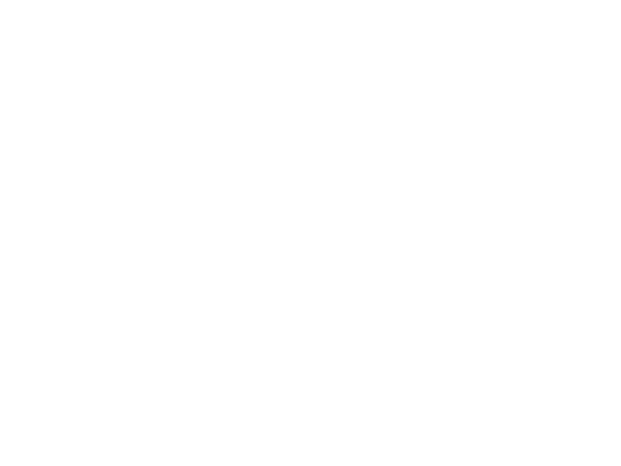

Displayed 12 image(s) from the PDF.


In [34]:
# Display PDF images as they are (PyMuPDF + IPython.display.Image)
import fitz  # PyMuPDF
from IPython.display import display, Image, HTML

doc = fitz.open(PDF_PATH)
shown = 0
max_images = 12  # show first 12 images
for page_num in range(len(doc)):
    if shown >= max_images:
        break
    page = doc[page_num]
    for img_index, img in enumerate(page.get_images()):
        if shown >= max_images:
            break
        xref = img[0]
        try:
            base = doc.extract_image(xref)
            img_bytes = base["image"]
            ext = base["ext"]
            display(HTML(f"<p><b>Page {page_num+1}, image {shown+1}</b></p>"))
            display(Image(data=img_bytes, format=ext))
            shown += 1
        except Exception as e:
            pass
doc.close()
if shown == 0:
    print("No embedded images extracted.")
else:
    print(f"Displayed {shown} image(s) from the PDF.")

In [35]:
# Document metadata from PDF (title, author, etc.)
first_meta = page_chunks[0].get("metadata", {}) if page_chunks else {}
print("PDF document metadata:")
for k, v in first_meta.items():
    if v is not None and str(v).strip():
        print(f"  {k}: {v}")

PDF document metadata:
  format: PDF 1.5
  creator: LaTeX with hyperref package
  producer: pdfTeX-1.40.12
  creationDate: D:20161230012255Z
  modDate: D:20161230012255Z
  file_path: ./input_docs/FasterR_CNN.pdf
  page_count: 17
  page: 1


## Second research paper & comparison

Load the **next** research paper in the folder, show contents of **both** papers, and compare **images**, **text**, **equations**, and **tables**.

In [ ]:
# Load second research paper (next in folder)
if not PDF_PATH_2 or not os.path.isfile(PDF_PATH_2):
    print("No second PDF found. Add another PDF to ./input_docs or ./ResearchPapers.")
    page_chunks_2 = []
    documents_with_metadata_2 = []
else:
    import pymupdf4llm
    from langchain_core.documents import Document
    page_chunks_2 = pymupdf4llm.to_markdown(
        PDF_PATH_2,
        page_chunks=True,
        table_strategy="lines",
        show_progress=True,
    )
    documents_with_metadata_2 = []
    for i, chunk in enumerate(page_chunks_2):
        meta = dict(chunk.get("metadata", {}))
        page_num = meta.get("page_number") or meta.get("page") or (i + 1)
        if isinstance(page_num, int) and "page_number" not in meta:
            meta["page_number"] = page_num
        meta["source"] = meta.get("file_path") or PDF_PATH_2
        meta["page"] = page_num
        text = (chunk.get("text") or "").strip()
        tables = chunk.get("tables") or []
        images = chunk.get("images") or []
        graphics = chunk.get("graphics") or []
        toc = chunk.get("toc_items") or []
        meta["total_pages"] = len(page_chunks_2)
        meta["tables_on_page"] = len(tables)
        meta["images_on_page"] = len(images)
        meta["graphics_on_page"] = len(graphics)
        meta["toc_items"] = toc
        doc = Document(page_content=text, metadata=meta)
        documents_with_metadata_2.append(doc)
    print(f"Loaded second paper: {len(page_chunks_2)} pages, {len(documents_with_metadata_2)} documents.")

In [ ]:
# Show contents of both papers (first 2 pages each)
MAX_PREVIEW = 2000
for name, docs, path in [
    ("Paper 1", documents_with_metadata, PDF_PATH),
    ("Paper 2", documents_with_metadata_2, PDF_PATH_2 if PDF_PATH_2 else ""),
]:
    if not docs:
        continue
    print("=" * 70)
    print(f"{name}: {Path(path).name if path else 'N/A'}")
    print("=" * 70)
    for doc in docs[:2]:
        p = doc.metadata.get("page_number") or doc.metadata.get("page")
        text = (doc.page_content or "").strip()
        print(f"\n--- Page {p} ---\n")
        print(text[:MAX_PREVIEW] + ("..." if len(text) > MAX_PREVIEW else ""))
    print("\n")

### Comparison table: images, text length, equations, tables

Metrics are computed for each paper so you can compare structure and content.

In [ ]:
# Comparison: images, text, equations, tables from both papers
import re
import fitz

def count_equations(text):
    """Approximate equation count: parentheses/bracket pairs and $ $ often used in equations."""
    if not text:
        return 0
    # Pairs like ( x ) or [ y ] that may be equations; $...$; and LaTeX-like \frac, \sum, etc.
    parens = len(re.findall(r"\([^()]{2,}\)", text))
    brackets = len(re.findall(r"\[[^\[\]]{2,}\]", text))
    dollar = len(re.findall(r"\$[^$]+\$", text))
    latex = len(re.findall(r"\\frac|\\sum|\\int|\\alpha|\\beta|\\theta", text))
    return min(parens + brackets + dollar + latex, 5000)  # cap for sanity

def count_images_fitz(pdf_path):
    if not pdf_path or not os.path.isfile(pdf_path):
        return 0
    doc = fitz.open(pdf_path)
    n = sum(len(page.get_images()) for page in doc)
    doc.close()
    return n

def stats_for_chunks(path, chunks, label):
    if not chunks:
        return {"Paper": label, "Pages": 0, "Total chars": 0, "Images": 0, "Tables": 0, "Equations (approx)": 0}
    total_chars = sum(len((c.get("text") or "")) for c in chunks)
    total_tables = sum(len(c.get("tables") or []) for c in chunks)
    all_text = " ".join((c.get("text") or "") for c in chunks)
    eq = count_equations(all_text)
    im = count_images_fitz(path)
    return {
        "Paper": label,
        "Pages": len(chunks),
        "Total chars": total_chars,
        "Images": im,
        "Tables": total_tables,
        "Equations (approx)": eq,
    }

rows = [
    stats_for_chunks(PDF_PATH, page_chunks, Path(PDF_PATH).name),
]
if page_chunks_2 and PDF_PATH_2:
    rows.append(stats_for_chunks(PDF_PATH_2, page_chunks_2, Path(PDF_PATH_2).name))

# Display as table
from IPython.display import display, HTML
s = "<table border='1' cellpadding='8' style='border-collapse:collapse'><tr><th>Metric</th>"
for r in rows:
    s += f"<th>{r['Paper']}</th>"
s += "</tr>"
for key in ["Pages", "Total chars", "Images", "Tables", "Equations (approx)"]:
    s += f"<tr><td><b>{key}</b></td>"
    for r in rows:
        s += f"<td>{r[key]}</td>"
    s += "</tr>"
s += "</table>"
display(HTML("<h3>Comparison: Paper 1 vs Paper 2</h3>" + s))